*This is a Jupyter Notebook. It is an interactive document that contains both rich text elements such as figures, links, equations, etc. and executable code - in this case Python code (the grey boxes).
**How to use a Jupyter Notebook**: You can execute the blocks of code one at the time by placing the mouse in the grey box and pressing shift + enter. An asterisk will appear in the brackets at the top left of the box while the code is being executed (this may take few seconds) and turns into a number when the execution is over.*

*This notebook and underpinning code were developed by Francesca Pianosi (francesca.pianosi@bristol.ac.uk) and are distributed under the GPL 3.0 licence: https://www.gnu.org/licenses/gpl-3.0.html*

# Automatic calibration of the GR6J lumped rainfall-runoff model

This Notebooks implements the automatic calibration of the lumped rainfall-runoff model GR6J using time series of precipitation, potential evaporation, and river flows of an example catchment, the Wick River at Tarroul: https://nrfa.ceh.ac.uk/data/station/spatial/1001

**<span style="color:blue">How to use this Notebook</span>** 
* Execute and assess the code cells one at the time. Read the brief explanation before each cell to understand what the code is doing, and use the questions afterwards to reflect on what the numerical results are showing. 
* For most code cells, you will not need to modify the code - just execute it. But it may be helpful to read the code (and comments) to get a better understanding of what is going on.
* You will also find a few <span style="color:blue">Decision Points</span> where you will have to make a choice on a particular aspect of the modelling exercise. At those points, you will have to get into the subsequent code cell and edit the default choices in order to implement yours. You can always go back to these Decision Points to change your choices, re-execute the code, and see the impacts.

**<span style="color:blue">How to modify the Notebook for application to a different catchment</span>** 
* If you want to apply this Notebook to a different catchment, you only need to change the first line in the code cell **Load rainfall, evap and flow data** by replacing the file name "CAMELS_GB_1001.csv" with the name of the file where the time series for your catchment are saved. 
* This must be a csv file with three columns named "precipitation", "pet" and "discharge_spec" (as in the <span style="color:blue">header</span> of "CAMELS_GB_1001.csv"). Also, the three columns must not have gaps (or NaN) and all three variables must be expressed in <span style="color:blue">mm/day</span>.

### Import libraries

In [2]:
from __future__ import division, absolute_import, print_function

# General Python Packages needed for calculation
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Specific functions needed for model simulation and calibration
from GR6J import gr6j_sim as gr6j_sim
from PerfMetrics import CORR_ERR as CORR_ERR
from PerfMetrics import MEAN_ERR as MEAN_ERR
from PerfMetrics import STD_ERR as STD_ERR

# Python Packages for interactive visualisation in Jupyter Notebooks
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider
import warnings
warnings.filterwarnings('ignore') # to hide warning messages
from IPython.display import display, HTML
# Increase size of output display cell:
display(HTML("""
<style>
    div.output_scroll {height: 40em; }
</style>
"""))

### Load rainfall, evap and flow data

In [3]:
# Load the data:
data = pd.read_csv("CAMELS_GB_1001.csv")
rain = data["precipitation"].to_numpy() # (mm/year)
evap = data["pet"].to_numpy() # (mm/year)
flow = data["discharge_spec"].to_numpy() # (mm/year)

### Step 1: Going through the data to identify the datasets for automatic calibration
In this Notebook, we will automatise the process of model calibration, that is, identification of the parameter values that enable the model to best reproduce the rainfall-runoff relationship of this particular catchment.

To begin with, we want to identify two time periods that will be used to extract: <br>
(1) a dataset for the model calibration <br>
(2) a dataset for the model validation <br>
To this end, in the next block we create a slider to go through the entire available time series and visualise different portions. 

**What we are looking for?** Ideally, we would like both datasets to: 
* be sufficiently long to be representative of different hydrological years
* include a good mix of wet and dry conditions 
* not include unxeplained outliers

In [4]:
# Define interactive visualisation function to define time periods for the visualisation 
# of the prec, temp, and flow timeseries
N = len(rain)
def period_function(ini = 1, fin = 365 ):
    i = ini-1
    f = fin-1
    rain_plot = rain[i:f] 
    evap_plot = evap[i:f]
    flow_plot = flow[i:f]
    # Plot data:
    plt.figure(figsize=[15,7])
    plt.subplot(311); plt.plot(rain_plot,'g'); plt.ylabel('rainfall (mm/day)')
    plt.title("Period from day %g" % ini + " to day %g" % fin )
    plt.subplot(312); plt.plot(evap_plot,'g'); plt.ylabel('evaporation (mm/day)')
    plt.subplot(313); plt.plot(flow_plot,'g'); plt.ylabel('flow (mm/day)')
    plt.xlabel('time (days)')
    plt.show()
    
interact(period_function, ini = (1, N-1, 1), fin = (1,N-1,1));

interactive(children=(IntSlider(value=1, description='ini', max=7265, min=1), IntSlider(value=365, description…

### <span style="color:blue">Modelling decision 1: choose the periods for calibration and validation</span>
Now that we have explored the time series, in the next block of code we will assign the variables defining the initial and final day of the period that will be used from now on for the calibration and the validation of the model. 
**<span style="color:blue">You must edit the code in the next cell to implement your choice**</span>!

In [5]:
# Calibration datset: first two years
ini_cal = 1 # first day of the calibration datset
fin_cal = 365*5 # last day of the calibration dataset
# Validation datset: the following two years
ini_val = 366*10+1 # first day of the validation dataset
fin_val = 366*10+365*2 # last day of the validation dataset

Visualize the corresponding datasets:

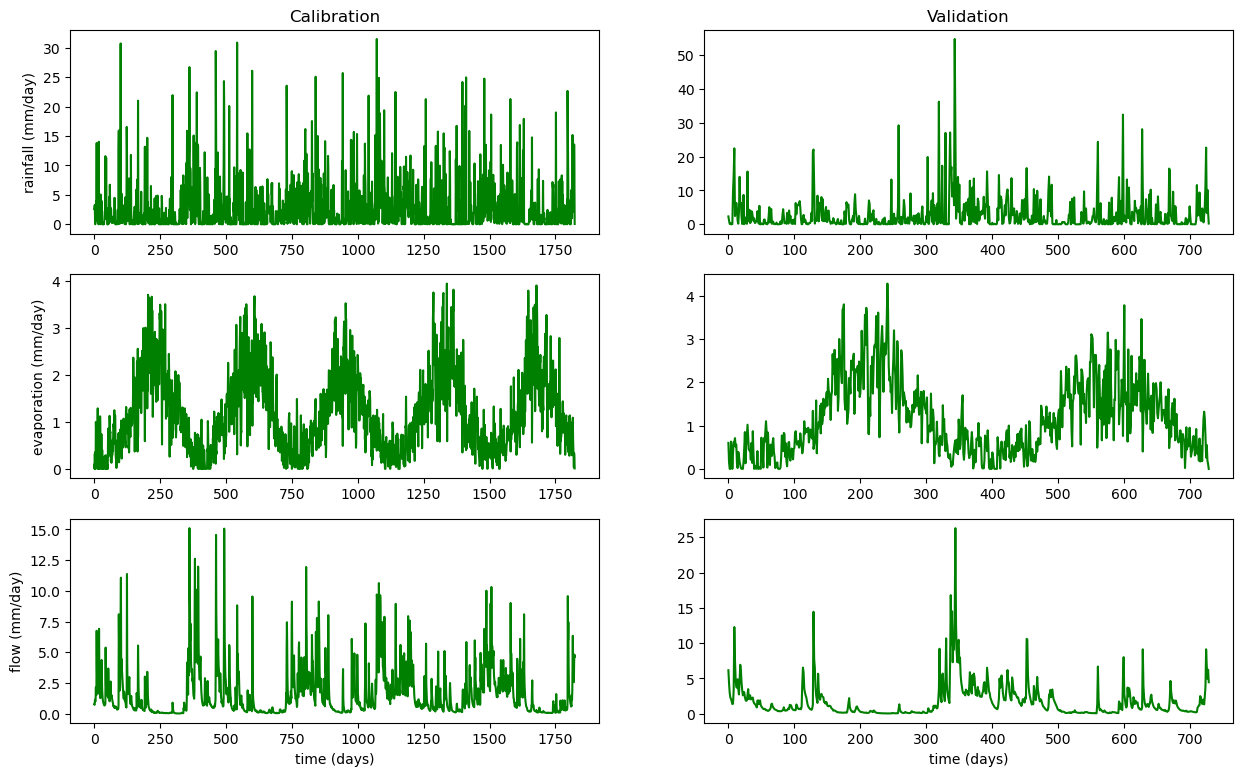

In [6]:
rain_cal = rain[ini_cal-1:fin_cal-1] 
evap_cal = evap[ini_cal-1:fin_cal-1]
flow_cal = flow[ini_cal-1:fin_cal-1]
rain_val = rain[ini_val-1:fin_val-1] 
evap_val = evap[ini_val-1:fin_val-1]
flow_val = flow[ini_val-1:fin_val-1]
# Plot data:
plt.figure(figsize=[15,9])
plt.subplot(321); plt.plot(rain_cal,'g'); plt.ylabel('rainfall (mm/day)'); plt.title("Calibration")
plt.subplot(322); plt.plot(rain_val,'g'); plt.title("Validation")
plt.subplot(323); plt.plot(evap_cal,'g'); plt.ylabel('evaporation (mm/day)')
plt.subplot(324); plt.plot(evap_val,'g'); 
plt.subplot(325); plt.plot(flow_cal,'g'); plt.ylabel('flow (mm/day)'); plt.xlabel('time (days)')
plt.subplot(326); plt.plot(flow_val,'g'); plt.xlabel('time (days)')

plt.show()

### Questions
* Are you happy with your choice?
* Are the two datasets sufficiently diverse (that is, each of them show a mix of wet and dry periods) while being sufficiently similar to one another (that is, there are no systematic difference between the two)?

### Step 2: Randomly generate N parameter combinations
Now that we have defined which dataset we are going to use for the model calibration, we can generate a sample of parameter combinations and test each of them over the calibration dataset. To this end, we must first of all decide the ranges from which parameters will be sampled, and the total number of samples (combinations) we want to test.

### <span style="color:blue">Modelling decision 2: choose the parameter ranges and number of parameter combinations</span>

**What we are looking for?** Ideally, we would like:

* Ranges that are sufficiently large so that we can reasonably assume they include the "optimal" value 
* ... but not so large to include parameter values that we would consider physically unrealistic
* A total number of samples sufficiently large to test many different parameter combinations
* ... but not so large that it take too long to complete the simulations!

**<span style="color:blue">Once you have made up your mind, you must edit the code in the next cell to implement your choice**</span>!

In [7]:
# Define variability ranges of the parameters:
xmin = [0  , 0,   10,  0, 0.1, 0.1] # min values
xmax = [300, 3,  50, 10, 0.5, 50  ] # max values

# Choose the number of samples:
N = 200 

### Use random sampling functions to generate the N parameter combinations
Now we can sample the prescribed numeber of parameter combinations from their ranges. To get a better grasp of what this means, we will visualise the first 5 parameter samples in a Table format.

In [8]:
X_Labels = ['x1', 'x2', 'x3', 'x4', 'x5','x6'] # Name of parameters (used to customize plots)
M = len(X_Labels) # Number of parameters
X = np.random.uniform(low=xmin, high=xmax, size=(N,M))
print("First 5 parameter samples: \n ", X[0:5,])


First 5 parameter samples: 
  [[1.46401212e+02 1.76881159e+00 1.31522921e+01 6.94784072e+00
  4.88684427e-01 2.55381656e+01]
 [2.07320130e+02 1.66114339e+00 4.15525924e+01 6.67607861e+00
  3.43114760e-01 2.75704318e+01]
 [1.70537173e+00 8.20710964e-01 3.31292758e+01 1.77754397e+00
  3.53269377e-01 4.45109725e+01]
 [1.95689511e+02 2.02943831e-01 4.23337842e+01 6.61095208e-01
  1.96795029e-01 4.32762525e+01]
 [2.18129103e+02 5.76516802e-01 1.09780997e+01 7.27544999e+00
  2.70630947e-01 2.85248044e+01]]


###  Step 3: Run the model against the N parameter combinations
Now we can simulate the model against each parameter combination and visualise the resulting flow timeseries:

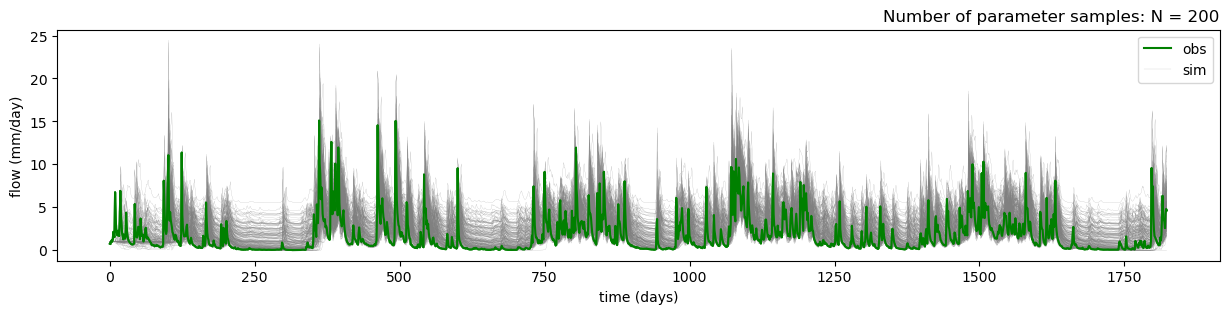

In [9]:
# Execute the model against all the input samples in 'X':
T = fin_cal-ini_cal
QQ = np.nan * np.ones((N,T)) 
for j in range(N):
    tmp = gr6j_sim(X[j, :],rain_cal, evap_cal, np.zeros((3, )))
    QQ[j,:]=tmp[0].flatten()

# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,3])
plt.plot(flow_cal, color='g') # plot for legend
plt.plot(np.transpose(QQ), 'grey', linewidth = 0.1)
plt.plot(flow_cal, color='g')
plt.ylabel('flow (mm/day)'); plt.xlabel('time (days)')
plt.legend(['obs', 'sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

### Calculate performance metrics and visualise their values for all parameter combinations
As we now have so many simulated time series, it is impossible to assess how each one of them compare to observations with a simple visual analysis - we need to automatise this assessment process. To this end, we can define one or more performance metric that will synthesise into one number the level of "fit-to-data" of each time series. In the following block, we will use three metrics (all to be minimised):

Timing: $ \ \ \ T = ( r - 1 )^2 \ \ $ where $ \ \ \ r = \text{correlation} ( Q^{sim}, Q^{obs} ) $
and $Q^{sim}$ ($Q^{obs}$) is the time series of simulated (observed) flow

Variability: $ \ \ \ V = ( S_{sim} / S_{obs} - 1 )^2 \ \ $ where $S_{sim}$ ($S^{obs}$) is the standard deviation of the time series $Q^{sim}$ ($Q^{obs}$).

Bias: $ \ \ \ B =  ( M_{sim} / M_{obs} - 1 )^2 \ \ $ where $M^{sim}$ ($M^{obs}$) is the mean of $Q^{sim}$ ($Q^{obs}$)

We will also use a fourth metric, which is widely used in hydrology under the name of King-Gupta Efficiency (https://en.wikipedia.org/wiki/Kling%E2%80%93Gupta_efficiency), and is a combination of T, V and B:

King-Gupta Efficiency: $ \ \ \ KGE = 1 - \sqrt{ T + V + B } $ 

By definition, KGE varies between $- \infty $ and 1, where 1 is the value that would be achieved by a perfect model with no error in timing, variability and bias. Differently from T, V and B thus, the KGE is to be maximised.

In [10]:
# Calculate performance metrics for each parameter sample:
YY = np.nan * np.ones((N, 4))
YY[:, 0] = CORR_ERR(QQ, flow_cal)
YY[:, 1] = MEAN_ERR(QQ, flow_cal)
YY[:, 2] = STD_ERR(QQ, flow_cal)
YY[:, 3] = 1 - ( YY[:, 0]+YY[:, 1]+YY[:, 2] )**0.5

Y_Labels = ['TIMING','BIAS','VARIABILITY','KGE']

def scatterplot_function(metric = 'TIMING' ):
    
    if metric == Y_Labels[0]:
        j = 0
    elif metric == Y_Labels[1]:
        j = 1
    elif metric == Y_Labels[2]:
        j = 2
    elif metric == Y_Labels[3]:
        j = 3
        
    plt.figure(figsize=[18,3])
    idx_opt = np.argmin(YY[:,j])
    if j == 3:
        idx_opt = np.argmax(YY[:,j])   
    for i in range(M):
        plt.subplot(1,M,i+1) 
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j]); 
        plt.xlabel(X_Labels[i])
        plt.plot(X[idx_opt, i], YY[idx_opt,j], 'o', markerfacecolor="grey", markeredgecolor="red")
        plt.title("opt: %0.2f" % X[idx_opt,i],color="r")
    print("Optimal value of performance metric: %0.6f " % YY[idx_opt,j])  
    
    plt.figure(figsize=[15,3])
    plt.plot(flow_cal, color='g') # plot for legend
    plt.plot(QQ[idx_opt,:], color='r')
    plt.plot(np.transpose(QQ), 'grey', linewidth = 0.1)
    plt.plot(flow_cal, color='g')
    plt.plot(QQ[idx_opt,:], color='r')
    plt.ylabel('flow (mm/day)'); plt.xlabel('time (days)')
    plt.legend(['obs','sim opt', 'sim'])
    plt.show()
    
interact(scatterplot_function, metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('TIMING', 'BIAS', 'VARIABILITY', 'KGE'), value='…

### <span style="color:blue">Modelling decision 3: choose the performance metric to find the optimal parameter values</span>
Now you have to choose which performance metric you want to use to identify the optimal parameter combination.
**<span style="color:blue">Edit the code in the next cell to implement your choice**</span>!

In [19]:
j=0 # choose TIMING
#j=1 # choose BIAS
#j=2 # choose VARIABILITY
#j=3 # choose KGE
idx_opt = np.argmin(YY[:,j])
if j==3:
    idx_opt = np.argmax(YY[:,j])
x_opt = X[idx_opt,:]
print("Optimal parameter combination: \n", x_opt)

Optimal parameter combination: 
 [38.74008484  2.94382261 41.69319981  0.25330133  0.4719621  11.51137992]


### Step 4: Model evaluation
Now that the automatic calibration has identified an "optimal" parameter combination, we need to evaluate if we are happy with it or if we want to revise some of our choices and repeat the process to find a better combination.

**What we are looking for?** Ideally, we would like that
* the "optimal" parameter values make hydrological sense
* the model to retain good performance on a different dataset from the one used for validation (if this does not happen, the model may be overtrained)

### Test performance over validation dataset



In [1]:
# Run simulation:
flow_sim_cal, _, _ = gr6j_sim(x_opt, rain_cal, evap_cal, np.zeros((3, )))
flow_sim_val, _, _ = gr6j_sim(x_opt, rain_val, evap_val, np.zeros((3, )))

if j == 0:
    perf_cal = CORR_ERR(flow_sim_cal, flow_cal)
    perf_val = CORR_ERR(flow_sim_val, flow_val)
elif j == 1:
    perf_cal = MEAN_ERR(flow_sim_cal, flow_cal)
    perf_val = MEAN_ERR(flow_sim_val, flow_val)
elif j == 2:
    perf_cal = STD_ERR(flow_sim_cal, flow_cal)
    perf_val = STD_ERR(flow_sim_val, flow_val)
elif j == 3:
    perf_cal = 1 - ( CORR_ERR(flow_sim_cal, flow_cal)+MEAN_ERR(flow_sim_cal, flow_cal)+STD_ERR(flow_sim_cal, flow_cal) )**0.5
    perf_val = 1 - ( CORR_ERR(flow_sim_val, flow_val)+MEAN_ERR(flow_sim_val, flow_val)+STD_ERR(flow_sim_val, flow_val) )**0.5

# Plot results:
plt.figure(figsize=[15,3])
# Calibration dataset
plt.subplot(1,2,1) 
plt.plot(flow_cal, 'g') # observed flow
plt.plot(flow_sim_cal, 'k') # simulated flow
plt.ylabel('flow (mm/day)')
plt.xlabel('time (days)')
plt.title(Y_Labels[j] + " (cal) = %0.4f " % perf_cal)
plt.legend(['obs', 'sim'])
# Validation dataset
plt.subplot(1,2,2) 
plt.plot(flow_val, 'g') # observed flow
plt.plot(flow_sim_val, 'k') # simulated flow
plt.ylabel('flow (mm/day)')
plt.xlabel('time (days)')
plt.title(Y_Labels[j] + " (val) = %0.4f " % perf_val)
plt.legend(['obs', 'sim'])
plt.show()


NameError: name 'gr6j_sim' is not defined

### Questions
* *Are the performance sufficiently good on both calibration and validation dataset*?
* *If not, what modelling choice could you go back and change to identify a more satisfactory parameter combinations*?